### Dataset Builder: From Raw Tracking To Model-Ready Tensors

This cell builds the core dataset that Deep CoverageNet trains on. It takes raw tracking and play-level label files and converts them into fixed-shape tensors that represent **early defensive movement over the first 1.2 seconds (12 frames)**.

**Inputs**

- `supplementary_data.csv`  
  - Play-level information including `game_id`, `play_id`, `team_coverage_type`, and `team_coverage_man_zone`.
- `input_2023_w*.csv`  
  - Frame-level tracking for all players, pre-throw, weeks 1–18.

**Key design choices**

- **Early-frame window (T_FRAMES = 12)**  
  We only use the first 12 frames (~1.2 seconds) after the snap. This is the QB’s first-read window and the period where defenses either **declare** or **maintain disguise**. The model’s job is to infer coverage from that limited, high-value window.

- **Defensive-only, coverage-specific players**  
  The builder filters to defensive players (`player_side == "Defense"`) and, if available, roles tagged as `"Defensive Coverage"`. This focuses the representation on the 11 defenders responsible for the coverage shell.

- **Standardized field coordinates**  
  - `standardize_coords` flips x/y so the offense always moves left to right.  
  - `normalize_xy` scales positions into `[0, 1]` using a 120 × 53.3 field.  
  This removes team- and direction-specific artifacts so the model only sees football structure, not raw orientation noise.

- **Directional features**  
  - `add_direction_features` converts `dir` and `o` (orientation) into sine/cosine components.  
  - This captures movement and body orientation in a smooth, rotation-invariant way.

- **Consistent defender ordering**  
  - `role_priority` ranks defenders by position group (S/CB/LB/etc.) and then by field location (`y`, then `x`).  
  - Each frame is sorted using this priority and truncated/padded to exactly **11 defenders**.  
  - This gives a consistent [11, F] ordering per frame instead of a random permutation each play, which is critical for a CNN to learn spatial patterns.

**Tensor construction**

For each `(game_id, play_id)` group:

- Build a `[T, 11, F]` tensor (`build_play_tensor`):
  - Up to 12 frames (or padded with zeros if fewer exist).  
  - 11 defenders per frame, each with 8 features:  
    `["x_norm", "y_norm", "s", "a", "dir_sin", "dir_cos", "o_sin", "o_cos"]`.
- Plays that have no valid defenders or frames are skipped.

**Label mapping**

- `map_coverage_shell` groups raw coverage strings into 7 buckets: `C0, C1, C2, C3, C4, 2-MAN, OTHER`.
- `map_man_zone` groups into `MAN, ZONE, MIXED, OTHER`.
- We build integer mappings:
  - `shell_map`: `{bucket → index}`  
  - `man_zone_map`: `{bucket → index}`  
- These maps are saved to `label_maps.json` for use during training and interpretation.

**Outputs**

After processing all plays:

- `X_plays.pt`  
  - Shape `[N, T, 11, F]` — early defender movement tensors.
- `y_shell.pt`  
  - Shape `[N]` — coverage shell labels.
- `y_mz.pt`  
  - Shape `[N]` — man/zone labels.
- `label_maps.json`  
  - Stores category → index mappings for shells and man/zone.

**Dataset and sanity check**

- `CoverageDataset` wraps `(X, y_shell, y_mz)` into a standard PyTorch `Dataset` for later training.
- `example_dataloader()` loads the saved tensors, builds a `DataLoader`, and prints batch shapes to verify:
  - `X` batch: `[B, T, 11, F]`
  - `y_shell`: `[B]`
  - `y_mz`: `[B]`

In short, this cell is the **data backbone** of the project: it converts raw tracking and labels into a clean, standardized representation of early defensive structure that the model can learn from and that we can later use to reason about **which defenses are easy to read early and which ones genuinely disguise their coverages.**


In [20]:
"""
Deep CoverageNet – Dataset Builder

Inputs:
  - /supplementary_data.csv       (play-level labels)
  - /input_2023_w*.csv            (weeks 1–18 tracking, pre-throw)

Outputs (created in ./coverage_processed/):
  - X_plays.pt    : [N, T, 11, F] float32  (defenders early movement)
  - y_shell.pt    : [N] int64              (coverage shell bucket)
  - y_mz.pt       : [N] int64              (man/zone bucket)
  - label_maps.json

Also defines:
  - CoverageDataset(Dataset)
  - example_dataloader() to sanity-check shapes
"""

import glob
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader


# =========================
# CONFIG
# =========================

PLAY_FILE = "supplementary_data.csv"    # play-level labels
TRACKING_GLOB = "input_2023_w*.csv"     # tracking files live at filesystem root

T_FRAMES = 12                             # early window length (frames)
FIELD_LENGTH = 120.0
FIELD_WIDTH = 53.3

OUTPUT_DIR = Path("coverage_processed")
OUTPUT_DIR.mkdir(exist_ok=True)

X_OUT_PATH       = OUTPUT_DIR / "X_plays.pt"
Y_SHELL_OUT_PATH = OUTPUT_DIR / "y_shell.pt"
Y_MZ_OUT_PATH    = OUTPUT_DIR / "y_mz.pt"
LABEL_MAPS_PATH  = OUTPUT_DIR / "label_maps.json"

SIDE_COL = "player_side"         # "Offense" / "Defense"
ROLE_COL = "player_role"         # "Defensive Coverage", etc.
POS_COL  = "player_position"     # CB, S, LB, ...

DEF_SIDE_VALUE = "Defense"
KEEP_DEF_ROLES = ["Defensive Coverage"]  # restrict to coverage defenders

ROLE_PRIORITY = {
    "FS": 0, "SS": 0, "S": 0,
    "CB": 1, "DB": 1, "NB": 1,
    "LB": 2, "MLB": 2, "ILB": 2, "OLB": 2,
    "_OTHER": 3,
}


# =========================
# LABEL MAPPING
# =========================

def map_coverage_shell(raw: str) -> str:
    """
    Map raw team_coverage_type (e.g. 'COVER_2_ZONE', 'COVER_3_MATCH')
    to buckets: C0, C1, C2, C3, C4, 2-MAN, OTHER.
    """
    if not isinstance(raw, str):
        return "OTHER"
    s = raw.upper()
    if "TWO_MAN" in s or "2_MAN" in s:
        return "2-MAN"
    if "COVER_0" in s:
        return "C0"
    if "COVER_1" in s:
        return "C1"
    if "COVER_2" in s:
        return "C2"
    if "COVER_3" in s:
        return "C3"
    if "COVER_4" in s:
        return "C4"
    return "OTHER"


def map_man_zone(raw: str) -> str:
    """
    Map team_coverage_man_zone (e.g. 'ZONE_COVERAGE') to:
      ZONE, MAN, MIXED, OTHER.
    """
    if not isinstance(raw, str):
        return "OTHER"
    s = raw.upper()
    if "MIX" in s:
        return "MIXED"
    if "ZONE" in s and "MAN" not in s:
        return "ZONE"
    if "MAN" in s and "ZONE" not in s:
        return "MAN"
    return "OTHER"


def role_priority(pos: str) -> int:
    if not isinstance(pos, str):
        return ROLE_PRIORITY["_OTHER"]
    p = pos.upper()
    if p in ROLE_PRIORITY:
        return ROLE_PRIORITY[p]
    if p == "S":
        return ROLE_PRIORITY["S"]
    if "CB" in p or "DB" in p or "NB" in p:
        return ROLE_PRIORITY["CB"]
    if "LB" in p:
        return ROLE_PRIORITY["LB"]
    return ROLE_PRIORITY["_OTHER"]


# =========================
# FEATURE HELPERS
# =========================

def standardize_coords(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flip x/y so offense always goes left→right.
    """
    if "play_direction" not in df.columns:
        return df
    d = str(df["play_direction"].iloc[0]).lower()
    if d.startswith("left"):
        df["x"] = FIELD_LENGTH - df["x"]
        df["y"] = FIELD_WIDTH - df["y"]
    return df


def add_direction_features(df: pd.DataFrame) -> pd.DataFrame:
    if "dir" in df.columns:
        rad = np.deg2rad(df["dir"].astype(float))
        df["dir_sin"] = np.sin(rad)
        df["dir_cos"] = np.cos(rad)
    else:
        df["dir_sin"] = 0.0
        df["dir_cos"] = 1.0

    if "o" in df.columns:
        rad_o = np.deg2rad(df["o"].astype(float))
        df["o_sin"] = np.sin(rad_o)
        df["o_cos"] = np.cos(rad_o)
    else:
        df["o_sin"] = 0.0
        df["o_cos"] = 1.0

    return df


def normalize_xy(df: pd.DataFrame) -> pd.DataFrame:
    df["x_norm"] = df["x"] / FIELD_LENGTH
    df["y_norm"] = df["y"] / FIELD_WIDTH
    return df


# =========================
# BUILD TENSOR FOR ONE PLAY
# =========================

def build_play_tensor(df_play: pd.DataFrame,
                      t_frames: int = T_FRAMES) -> np.ndarray | None:
    """
    Build [T, 11, F] tensor for a single (game_id, play_id).

    Uses:
      - only defenders (DEF_SIDE_VALUE and KEEP_DEF_ROLES)
      - first t_frames frames
      - consistent defender ordering per frame
    """
    if df_play.empty:
        return None

    df = df_play.copy()
    df = standardize_coords(df)
    df = add_direction_features(df)
    df = normalize_xy(df)

    # defenders
    df = df[df[SIDE_COL] == DEF_SIDE_VALUE]
    if ROLE_COL in df.columns and KEEP_DEF_ROLES:
        df = df[df[ROLE_COL].isin(KEEP_DEF_ROLES)]
    if df.empty:
        return None

    df = df.sort_values("frame_id")
    frame_ids = df["frame_id"].unique()[:t_frames]
    if len(frame_ids) == 0:
        return None

    feat_cols = ["x_norm", "y_norm", "s", "a", "dir_sin", "dir_cos", "o_sin", "o_cos"]
    for col in feat_cols:
        if col not in df.columns:
            df[col] = 0.0

    F = len(feat_cols)
    frame_tensors: list[np.ndarray] = []

    for f_id in frame_ids:
        df_f = df[df["frame_id"] == f_id].copy()
        df_f["role_priority"] = df_f[POS_COL].apply(role_priority)
        df_f = df_f.sort_values(["role_priority", "y", "x"])
        df_f = df_f.head(11)  # at most 11 defenders
        n_def = len(df_f)

        if n_def < 11:
            pad = pd.DataFrame(np.zeros((11 - n_def, F), dtype="float32"),
                               columns=feat_cols)
            df_f = pd.concat([df_f[feat_cols], pad], ignore_index=True)
        else:
            df_f = df_f[feat_cols]

        frame_tensors.append(df_f.to_numpy(dtype="float32"))

    # pad frames if needed
    while len(frame_tensors) < t_frames:
        frame_tensors.append(np.zeros((11, F), dtype="float32"))

    return np.stack(frame_tensors[:t_frames], axis=0)  # [T, 11, F]


# =========================
# MAIN BUILD FUNCTION
# =========================

def main_build_coverage_dataset():
    # ---- Load play-level labels ----
    print("Loading play-level labels from:", PLAY_FILE)
    plays = pd.read_csv(PLAY_FILE)
    plays["shell_bucket"] = plays["team_coverage_type"].apply(map_coverage_shell)
    plays["mz_bucket"] = plays["team_coverage_man_zone"].apply(map_man_zone)
    plays = plays[plays["shell_bucket"].notnull()].copy()
    print("Plays with labels:", len(plays))

    # ---- Load tracking files ----
    print("\nLoading tracking...")
    print("Glob pattern:", TRACKING_GLOB)
    tracking_files = sorted(glob.glob(TRACKING_GLOB))
    print("Tracking files found:", tracking_files)

    if not tracking_files:
        raise RuntimeError("No tracking files matched TRACKING_GLOB. "
                           "Check the path and filenames.")

    tracking = pd.concat([pd.read_csv(fp) for fp in tracking_files],
                         ignore_index=True)
    print("Total tracking rows:", len(tracking))

    # ---- Merge ----
    print("\nMerging tracking with labels...")
    merged = tracking.merge(
        plays[["game_id", "play_id", "shell_bucket", "mz_bucket"]],
        on=["game_id", "play_id"],
        how="inner"
    )
    print("Merged tracking rows:", len(merged))

    # ---- Build label maps ----
    shell_vals = sorted(merged["shell_bucket"].unique())
    mz_vals = sorted(merged["mz_bucket"].unique())
    shell_map = {s: i for i, s in enumerate(shell_vals)}
    mz_map = {s: i for i, s in enumerate(mz_vals)}

    with open(LABEL_MAPS_PATH, "w") as f:
        json.dump({"shell_map": shell_map, "man_zone_map": mz_map}, f, indent=2)

    print("Shell label map:", shell_map)
    print("Man/zone label map:", mz_map)

    # ---- Build tensors play-by-play ----
    print("\nBuilding play tensors...")
    X_list: list[np.ndarray] = []
    y_shell_list: list[int] = []
    y_mz_list: list[int] = []

    for i, ((gid, pid), df_play) in enumerate(
        merged.groupby(["game_id", "play_id"]), start=1
    ):
        Xp = build_play_tensor(df_play, T_FRAMES)
        if Xp is None:
            continue

        shell = df_play["shell_bucket"].iloc[0]
        mz = df_play["mz_bucket"].iloc[0]

        X_list.append(Xp)
        y_shell_list.append(shell_map[shell])
        y_mz_list.append(mz_map[mz])

        if i % 200 == 0:
            print(f"Processed {i} plays; valid samples so far: {len(X_list)}")

    if not X_list:
        raise RuntimeError("No valid plays built; check filters and data.")

    X = torch.from_numpy(np.stack(X_list, axis=0))       # [N, T, 11, F]
    y_shell = torch.tensor(y_shell_list, dtype=torch.long)
    y_mz = torch.tensor(y_mz_list, dtype=torch.long)

    torch.save(X, X_OUT_PATH)
    torch.save(y_shell, Y_SHELL_OUT_PATH)
    torch.save(y_mz, Y_MZ_OUT_PATH)

    print("\nDONE.")
    print("X shape      :", X.shape)
    print("y_shell shape:", y_shell.shape)
    print("y_mz shape   :", y_mz.shape)
    print("Saved tensors in:", OUTPUT_DIR)


# =========================
# DATASET + DATALOADER
# =========================

class CoverageDataset(Dataset):
    """
    Each item:
      X       : [T, 11, F] float32
      y_shell : scalar int64
      y_mz    : scalar int64
    """
    def __init__(self, X: torch.Tensor,
                 y_shell: torch.Tensor,
                 y_mz: torch.Tensor):
        assert X.shape[0] == y_shell.shape[0] == y_mz.shape[0]
        self.X = X
        self.y_shell = y_shell
        self.y_mz = y_mz

    def __len__(self) -> int:
        return self.X.shape[0]

    def __getitem__(self, idx: int):
        return self.X[idx], self.y_shell[idx], self.y_mz[idx]


def example_dataloader(batch_size: int = 8) -> DataLoader:
    X = torch.load(X_OUT_PATH)
    y_shell = torch.load(Y_SHELL_OUT_PATH)
    y_mz = torch.load(Y_MZ_OUT_PATH)

    ds = CoverageDataset(X, y_shell, y_mz)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    xb, ys, ym = next(iter(dl))
    print("\nSanity check batch:")
    print("  X batch shape      :", xb.shape)   # [B, T, 11, F]
    print("  y_shell batch shape:", ys.shape)   # [B]
    print("  y_mz batch shape   :", ym.shape)   # [B]
    return dl


# =========================
# RUN ONCE
# =========================

if __name__ == "__main__":
    main_build_coverage_dataset()
    example_dataloader(16)


Loading play-level labels from: supplementary_data.csv
Plays with labels: 18009

Loading tracking...
Glob pattern: input_2023_w*.csv
Tracking files found: ['input_2023_w01.csv', 'input_2023_w02.csv', 'input_2023_w03.csv', 'input_2023_w04.csv', 'input_2023_w05.csv', 'input_2023_w06.csv', 'input_2023_w07.csv', 'input_2023_w08.csv', 'input_2023_w09.csv', 'input_2023_w10.csv', 'input_2023_w11.csv', 'input_2023_w12.csv', 'input_2023_w13.csv', 'input_2023_w14.csv', 'input_2023_w15.csv', 'input_2023_w16.csv', 'input_2023_w17.csv', 'input_2023_w18.csv']


/tmp/ipython-input-56519311.py:237: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv(PLAY_FILE)


Total tracking rows: 4880579

Merging tracking with labels...
Merged tracking rows: 4880579
Shell label map: {'2-MAN': 0, 'C0': 1, 'C1': 2, 'C2': 3, 'C3': 4, 'C4': 5, 'OTHER': 6}
Man/zone label map: {'MAN': 0, 'OTHER': 1, 'ZONE': 2}

Building play tensors...
Processed 200 plays; valid samples so far: 200
Processed 400 plays; valid samples so far: 400
Processed 600 plays; valid samples so far: 600
Processed 800 plays; valid samples so far: 800
Processed 1000 plays; valid samples so far: 1000
Processed 1200 plays; valid samples so far: 1200
Processed 1400 plays; valid samples so far: 1400
Processed 1600 plays; valid samples so far: 1600
Processed 1800 plays; valid samples so far: 1800
Processed 2000 plays; valid samples so far: 2000
Processed 2200 plays; valid samples so far: 2200
Processed 2400 plays; valid samples so far: 2400
Processed 2600 plays; valid samples so far: 2600
Processed 2800 plays; valid samples so far: 2800
Processed 3000 plays; valid samples so far: 3000
Processed 3200

### Baseline models on summary features

This cell trains two classical baselines on a compressed representation of each play. The goal is to benchmark how much signal exists in simple summary features before moving to deep models.

**Inputs**

- `X_plays.pt`: tensor of shape `[N, 12, 11, 8]` containing early defender movement  
- `y_shell.pt`: tensor of shape `[N]` with integer shell labels  
- `label_maps.json`: mapping between integer labels and shell names  

**Summary feature design**

To make the problem compatible with scikit learn models, we collapse the full spatiotemporal tensor into a fixed length feature vector per play:

- Take the **first frame** `[11, 8]`, flatten to 88 features  
- Take the **mean over time** across the 12 frames, giving another `[11, 8]` and 88 features  
- Concatenate first frame and time average to obtain a **176 dimensional** feature vector per play

This preserves:

- Instantaneous alignment at the snap (first frame)  
- Average movement and positioning over the early 1.2 second window (time mean)

The helper `make_summary_features` performs this transformation.

**Label filtering**

- If the shell map includes an `"OTHER"` class, those samples are removed to reduce label noise and focus on the main coverage buckets.
- We track which integer labels remain and derive their string names for cleaner reports.

**Train validation split**

- Use `train_test_split` with:
  - `test_size = 0.2`  
  - `stratify = y` to preserve label distribution  
  - `random_state = 42` for reproducibility

This yields `X_train, X_val, y_train, y_val` for baseline evaluation.

**Baseline 1: Multinomial logistic regression**

- Model: `LogisticRegression(multi_class="multinomial", max_iter=1000, n_jobs=-1)`  
- Trained on the 176 dimensional feature vectors  
- Evaluated with:
  - Overall accuracy  
  - Macro F1 score  
  - Per class precision/recall/F1 via `classification_report`

Logistic regression provides a linear decision boundary baseline: it tests whether early movement is linearly separable across shells.

**Baseline 2: Random forest**

- Model: `RandomForestClassifier` with:
  - `n_estimators = 300`  
  - `class_weight = "balanced"` to compensate for shell imbalance  
  - `n_jobs = -1` and fixed `random_state`  
- Evaluated using the same metrics as logistic regression

The random forest captures nonlinear interactions between defender positions and movement in the summary features, providing a stronger classical baseline.

**Why these baselines matter**

- They quantify how much coverage information is available in **simple, compressed summaries** of the first 1.2 seconds.  
- They give a reference point for Deep CoverageNet:
  - If the CNN meaningfully outperforms these baselines, it shows that the full `[12, 11, 8]` tensor and learned spatiotemporal features are adding real value beyond snapshot and average statistics.
- They also help validate the preprocessing pipeline. If baselines cannot learn anything at all, it is a signal to re check label quality or feature construction.


In [21]:
"""
train_baselines.py

Baselines for Deep CoverageNet:
  - Multinomial logistic regression
  - Random forest

Uses:
  coverage_processed/X_plays.pt   (N, 12, 11, 8)
  coverage_processed/y_shell.pt   (N,)

Builds summary features per play:
  - first-frame defenders flattened (11*8 = 88)
  - time-averaged defenders flattened (88)
  -> concat -> 176-dim feature vector per play
"""

import json
from pathlib import Path

import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# =========================
# CONFIG
# =========================

DATA_DIR = Path("coverage_processed")
X_PATH = DATA_DIR / "X_plays.pt"
Y_SHELL_PATH = DATA_DIR / "y_shell.pt"
LABEL_MAPS_PATH = DATA_DIR / "label_maps.json"

TEST_SIZE = 0.2
RANDOM_STATE = 42

# =========================
# LOAD DATA
# =========================

print("Loading tensors...")
X = torch.load(X_PATH)              # [N, 12, 11, 8]
y_shell = torch.load(Y_SHELL_PATH)  # [N]

print("X shape:", X.shape)
print("y_shell shape:", y_shell.shape)

with open(LABEL_MAPS_PATH, "r") as f:
    label_maps = json.load(f)
shell_map = label_maps["shell_map"]
inv_shell_map = {v: k for k, v in shell_map.items()}
print("Shell classes (full map):", inv_shell_map)

# =========================
# FEATURE ENGINEERING
# =========================

def make_summary_features(X_tensor: torch.Tensor) -> np.ndarray:
    """
    X_tensor: [N, T, 11, F] = [N, 12, 11, 8]

    Returns:
        features: [N, D] numpy float32

    Features:
      - first frame flattened
      - mean over time flattened
    => D = 2 * (11 * 8) = 176
    """
    X_np = X_tensor.numpy()  # float32, [N, 12, 11, 8]

    first = X_np[:, 0, :, :]                 # [N, 11, 8]
    first_flat = first.reshape(first.shape[0], -1)   # [N, 88]

    mean_time = X_np.mean(axis=1)            # [N, 11, 8]
    mean_flat = mean_time.reshape(mean_time.shape[0], -1)  # [N, 88]

    features = np.concatenate([first_flat, mean_flat], axis=1).astype("float32")
    return features

print("\nBuilding summary features for baselines...")
X_feat = make_summary_features(X)   # [N, 176]
y = y_shell.numpy()

print("Feature matrix shape:", X_feat.shape)

# Drop 'OTHER' shell to reduce label noise (if present)
OTHER_ID = None
for k, v in shell_map.items():
    if k == "OTHER":
        OTHER_ID = v
        break

if OTHER_ID is not None:
    mask = y != OTHER_ID
    X_feat = X_feat[mask]
    y = y[mask]
    print(f"Filtered out 'OTHER' shell (id={OTHER_ID}). Remaining samples: {X_feat.shape[0]}")
else:
    print("No 'OTHER' class in shell_map; using all samples.")

# After filtering, define the actual labels used in this run
unique_labels = sorted(np.unique(y))
target_names = [inv_shell_map[i] for i in unique_labels]
print("Unique label IDs used:", unique_labels)
print("Target names used   :", target_names)

# =========================
# TRAIN / VALIDATION SPLIT
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X_feat,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("\nTrain size:", X_train.shape[0])
print("Val size  :", X_val.shape[0])

# =========================
# BASELINE 1 – LOGISTIC REGRESSION
# =========================

print("\n=== Baseline 1: Multinomial Logistic Regression ===")

log_reg = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000,
    n_jobs=-1,
)

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_val)

acc_lr = accuracy_score(y_val, y_pred_lr)
f1_macro_lr = f1_score(y_val, y_pred_lr, average="macro")

print(f"LogReg Accuracy   : {acc_lr:.4f}")
print(f"LogReg Macro F1   : {f1_macro_lr:.4f}")
print("Per-class report (shell buckets):")
print(classification_report(
    y_val,
    y_pred_lr,
    labels=unique_labels,
    target_names=target_names,
))

# =========================
# BASELINE 2 – RANDOM FOREST
# =========================

print("\n=== Baseline 2: Random Forest ===")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

acc_rf = accuracy_score(y_val, y_pred_rf)
f1_macro_rf = f1_score(y_val, y_pred_rf, average="macro")

print(f"RF Accuracy       : {acc_rf:.4f}")
print(f"RF Macro F1       : {f1_macro_rf:.4f}")
print("Per-class report (shell buckets):")
print(classification_report(
    y_val,
    y_pred_rf,
    labels=unique_labels,
    target_names=target_names,
))

print("\nBaselines complete.")



Loading tensors...
X shape: torch.Size([14107, 12, 11, 8])
y_shell shape: torch.Size([14107])
Shell classes (full map): {0: '2-MAN', 1: 'C0', 2: 'C1', 3: 'C2', 4: 'C3', 5: 'C4', 6: 'OTHER'}

Building summary features for baselines...
Feature matrix shape: (14107, 176)
Filtered out 'OTHER' shell (id=6). Remaining samples: 12678
Unique label IDs used: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Target names used   : ['2-MAN', 'C0', 'C1', 'C2', 'C3', 'C4']

Train size: 10142
Val size  : 2536

=== Baseline 1: Multinomial Logistic Regression ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg Accuracy   : 0.4815
LogReg Macro F1   : 0.3967
Per-class report (shell buckets):
              precision    recall  f1-score   support

       2-MAN       0.00      0.00      0.00        47
          C0       0.65      0.43      0.52       120
          C1       0.48      0.44      0.46       635
          C2       0.52      0.38      0.44       368
          C3       0.48      0.63      0.54       897
          C4       0.44      0.39      0.42       469

    accuracy                           0.48      2536
   macro avg       0.43      0.38      0.40      2536
weighted avg       0.48      0.48      0.47      2536


=== Baseline 2: Random Forest ===
RF Accuracy       : 0.5532
RF Macro F1       : 0.4545
Per-class report (shell buckets):
              precision    recall  f1-score   support

       2-MAN       0.00      0.00      0.00        47
          C0       0.74      0.53      0.62       120
          C1       0.57      0.42      0.48       635
          C2       0.84      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Deep CoverageNet: 2D CNN on defender movement

This cell defines and trains the main Deep CoverageNet model.

**What this script does**

- Loads:
  - `X_plays.pt` `[N, 12, 11, 8]` early frame defender tensors.
  - `y_shell.pt` shell labels and the label maps.
- Drops the `OTHER` coverage class if present.
- Remaps label IDs to a compact `[0 .. C-1]` index range for stable training.
- Wraps the tensors in a `CoverageShellDataset`:
  - Each item returns `x` as `[F, T, 11]` for Conv2d and the corresponding label.
- Splits the dataset into train and validation subsets.
- Defines a 2D CNN that operates on the `(time, defender)` grid:
  - Input shape to the model: `[B, C = features, H = time, W = defenders]`.
- Trains the CNN for a fixed number of epochs.
- Tracks train and validation:
  - Loss.
  - Accuracy.
  - Macro F1.
- Runs a final evaluation and prints a `classification_report` with shell names.

**Why 2D CNN on time × defenders**

- The tensors are structured as `[T, 11, F]`:
  - T is frames in time.
  - 11 defenders are the spatial dimension.
  - F is the feature channel dimension.
- By permuting to `[F, T, 11]` and feeding into Conv2d:
  - Convolutions can capture local patterns in both time and defender space.
  - Examples: safety rotation depth, corner leverage changes, apex alignment shifts, and how these evolve over the first 1.2 seconds.

**Model architecture**

- `CoverageCNN` has:
  - Three convolutional blocks with:
    - `Conv2d` + `BatchNorm2d` + `ReLU`.
    - Two `MaxPool2d` layers to gradually downsample the `(T, 11)` grid.
  - A fully connected head:
    - Flatten.
    - Linear layer to 256 units + ReLU + Dropout.
    - Final linear layer to `num_classes`.
- With `T=12` and `W=11`, the pooling steps are chosen so the spatial dimensions reduce to about `[3, 2]`, giving a manageable flattened size.

**Training and evaluation**

- Uses `CrossEntropyLoss` and `AdamW` optimizer.
- `run_epoch` supports both training and evaluation:
  - Accumulates loss over the loader.
  - Collects predictions and labels.
  - Computes accuracy and macro F1 with scikit learn.
- The main training loop:
  - Runs for `EPOCHS` epochs.
  - Prints train and validation loss, accuracy, and macro F1 each epoch to monitor learning.
- Final evaluation:
  - Runs one more pass on the validation loader.
  - Maps internal label indices back to original shell IDs.
  - Prints a `classification_report` with human readable shell names.
  - Prints final accuracy and macro F1, which are the headline numbers in the report.

This CNN is the primary Deep CoverageNet model and is the one used to study where early frame movement is predictive, where it is ambiguous, and how that ambiguity lines up with defensive disguise.


In [22]:
"""
cnn_coverage_net.py

Deep CoverageNet model using a 2D CNN on defender movement:

Input:
  X: [N, T, 11, F]  (from coverage_processed/X_plays.pt)
     T = 12 frames, 11 defenders, F = 8 features
  We reshape to:
     [N, C=F, H=T, W=11] and apply Conv2d over (time × space).

Target:
  y_shell: coverage shell bucket (without 'OTHER').

Outputs:
  - Epoch-by-epoch train / val accuracy and macro F1
  - Final classification_report vs shell labels
"""

import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================
# CONFIG
# =========================

DATA_DIR = Path("coverage_processed")
X_PATH = DATA_DIR / "X_plays.pt"
Y_SHELL_PATH = DATA_DIR / "y_shell.pt"
LABEL_MAPS_PATH = DATA_DIR / "label_maps.json"

BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3
VAL_SPLIT = 0.2
RANDOM_SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# DATASET
# =========================

class CoverageShellDataset(Dataset):
    def __init__(self, X: torch.Tensor, y_shell: torch.Tensor):
        """
        X: [N, T, 11, F]
        y_shell: [N]
        """
        assert X.shape[0] == y_shell.shape[0]
        self.X = X
        self.y = y_shell

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        # reshape to [C, H, W] for Conv2d
        # X[idx]: [T, 11, F]  -> [F, T, 11]
        x = self.X[idx].permute(2, 0, 1)  # [F, T, 11]
        y = self.y[idx]
        return x, y


# =========================
# LOAD TENSORS & FILTER 'OTHER'
# =========================

print("Loading tensors from", DATA_DIR)
X = torch.load(X_PATH)          # [N, 12, 11, 8]
y_shell = torch.load(Y_SHELL_PATH)  # [N]

print("Raw X shape:", X.shape)
print("Raw y_shell shape:", y_shell.shape)

with open(LABEL_MAPS_PATH, "r") as f:
    label_maps = json.load(f)
shell_map = label_maps["shell_map"]
inv_shell_map = {v: k for k, v in shell_map.items()}
print("Full shell map:", inv_shell_map)

# Drop 'OTHER' class if present
OTHER_ID = None
for k, v in shell_map.items():
    if k == "OTHER":
        OTHER_ID = v
        break

if OTHER_ID is not None:
    mask = y_shell != OTHER_ID
    X = X[mask]
    y_shell = y_shell[mask]
    print(f"Filtered out 'OTHER' shell (id={OTHER_ID}). Remaining samples: {X.shape[0]}")
else:
    print("No 'OTHER' shell class detected; using all samples.")

# Recompute unique labels & names for this run
unique_labels = sorted(torch.unique(y_shell).tolist())
target_names = [inv_shell_map[i] for i in unique_labels]
n_classes = len(unique_labels)
print("Unique label IDs:", unique_labels)
print("Target names   :", target_names)
print("Num classes    :", n_classes)

# Map labels to [0..C-1] for stability (in case IDs are not 0..C-1)
label_id_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
idx_to_label_id = {i: lbl for lbl, i in label_id_to_idx.items()}

y_idx = torch.tensor(
    [label_id_to_idx[int(lbl)] for lbl in y_shell.tolist()],
    dtype=torch.long
)


# =========================
# TRAIN / VAL SPLIT
# =========================

torch.manual_seed(RANDOM_SEED)

dataset = CoverageShellDataset(X, y_idx)
n_total = len(dataset)
n_val = int(VAL_SPLIT * n_total)
n_train = n_total - n_val

train_ds, val_ds = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

print(f"Train samples: {n_train}, Val samples: {n_val}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


# =========================
# CNN MODEL
# =========================

class CoverageCNN(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()
        # Input: [B, C=in_channels, H=T, W=11]
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # -> roughly [T/2, 11/2]

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # -> roughly [T/4, 11/4]

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        # With T=12, W=11, after two 2x2 pools:
        # H ≈ 12 -> 6 -> 3
        # W ≈ 11 -> 5 -> 2
        # So shape ≈ [B, 128, 3, 2] -> 128*3*2 = 768
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x


in_channels = X.shape[-1]  # F = 8
model = CoverageCNN(in_channels=in_channels, num_classes=n_classes).to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


# =========================
# TRAINING & EVAL LOOPS
# =========================

def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    all_preds = []
    all_labels = []
    running_loss = 0.0
    count = 0

    for xb, yb in loader:
        xb = xb.to(device, dtype=torch.float32)  # [B, C, H, W]
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * xb.size(0)
        count += xb.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = running_loss / count
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1_macro, all_labels, all_preds


print("\nStarting CNN training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1, _, _ = run_epoch(val_loader, train=False)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} F1 {train_f1:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}"
    )


# =========================
# FINAL EVAL & REPORT
# =========================

_, _, _, val_labels_idx, val_preds_idx = run_epoch(val_loader, train=False)

# map back to original shell IDs for reporting
val_labels_ids = [idx_to_label_id[i] for i in val_labels_idx]
val_preds_ids = [idx_to_label_id[i] for i in val_preds_idx]

# sklearn expects ints, so convert to numpy arrays
val_labels_ids = np.array(val_labels_ids)
val_preds_ids = np.array(val_preds_ids)

# classification_report with human-readable names
print("\nFinal CNN classification report (shell buckets):")
print(
    classification_report(
        val_labels_ids,
        val_preds_ids,
        labels=unique_labels,
        target_names=target_names,
    )
)

# compute and print final accuracy / macro F1 for the report
final_acc = accuracy_score(val_labels_ids, val_preds_ids)
final_f1 = f1_score(val_labels_ids, val_preds_ids, average="macro")
print(f"\nFinal CNN Accuracy : {final_acc:.4f}")
print(f"Final CNN Macro F1 : {final_f1:.4f}")


Using device: cuda
Loading tensors from coverage_processed
Raw X shape: torch.Size([14107, 12, 11, 8])
Raw y_shell shape: torch.Size([14107])
Full shell map: {0: '2-MAN', 1: 'C0', 2: 'C1', 3: 'C2', 4: 'C3', 5: 'C4', 6: 'OTHER'}
Filtered out 'OTHER' shell (id=6). Remaining samples: 12678
Unique label IDs: [0, 1, 2, 3, 4, 5]
Target names   : ['2-MAN', 'C0', 'C1', 'C2', 'C3', 'C4']
Num classes    : 6
Train samples: 10143, Val samples: 2535
CoverageCNN(
  (features): Sequential(
    (0): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0

### GRU Model: Temporal Baseline for Early Defender Movement

This script implements **CoverageGRU**, a second deep model for Deep CoverageNet that focuses on the *temporal* evolution of defender movement.

**What this script does**

- **Loads processed tensors**  
  - `X`: `[N, T, 11, F]` from `coverage_processed/X_plays.pt`  
    - `T = 12` early frames, `11` defenders, `F = 8` features per defender  
  - `y_shell`: integer coverage shell labels from `coverage_processed/y_shell.pt`  
  - Drops the `"OTHER"` shell bucket if present and remaps labels to a compact range `[0..C-1]`.

- **Builds a sequence dataset for the GRU**
  - Each frame `t` for a play has shape `[11, 8]` (defenders × features).  
  - We **flatten defenders and features per frame** into a single 88-dim vector:  
    - `frame_t -> [11, 8] -> 88`  
  - Each play becomes a sequence of length `T = 12`:  
    - shape `[T, 88]` → this is the GRU input.  
  - `CoverageGRUDataset` returns `(x, y)` where:
    - `x`: `[T, 88]` sequence of early defender movement  
    - `y`: shell label index in `[0..C-1]`.

- **Train / validation split**
  - Uses `random_split` with a fixed seed to create train/val sets based on `VAL_SPLIT = 0.2`.  
  - Wraps them in `DataLoader`s for mini-batch training.

- **GRU architecture (CoverageGRU)**
  - 2-layer **bidirectional GRU**:
    - `input_size = 88` (flattened defenders × features per frame)  
    - `hidden_size = 128`, `num_layers = 2`, `bidirectional = True`  
  - The GRU processes the 12-frame sequence and outputs hidden states for each time step.  
  - We take the **last time step’s hidden state** (concatenated across directions) as the summary of the entire early window.  
  - This summary vector feeds into a small MLP:
    - Linear → ReLU → Dropout → Linear → `num_classes` logits.

- **Training / evaluation loop**
  - `run_epoch` handles both train and validation:
    - Moves batches to `device`  
    - Computes cross-entropy loss  
    - Optionally backprop + optimizer step when `train=True`  
    - Tracks predictions and labels to compute:
      - Accuracy  
      - Macro F1 score  
  - Main loop runs for `EPOCHS = 15` and prints per-epoch train/val loss, accuracy, and macro F1.

- **Final reporting**
  - After training, runs a final pass on the validation set.  
  - Maps internal label indices back to the original shell IDs.  
  - Prints a `classification_report` with human-readable shell names and reports:
    - Final validation accuracy  
    - Final validation macro F1

**Why this model exists in the project**

- The GRU treats each play as a **time series of early defender configurations**, focusing on how structure evolves over the first 1.2 seconds.  
- It serves as a **temporal deep baseline** against the CNN:
  - CNN learns **local spatiotemporal patterns** across defenders and time.  
  - GRU focuses more purely on **time dynamics** of the flattened defensive structure.  
- Comparing GRU vs CNN helps show how much of the signal comes from:
  - Temporal dynamics alone vs  
  - Joint spatial–temporal structure.


In [23]:
"""
gru_coverage_net.py

Second deep model for Deep CoverageNet:
  - GRU over early defender movement.

Input tensors (already built):
  X: [N, T, 11, F] from coverage_processed/X_plays.pt
     T = 12 frames, 11 defenders, F = 8 features
  y_shell: coverage shell labels from coverage_processed/y_shell.pt

We flatten defenders×features per frame:
  frame_t = X[n, t, :, :]  ->  [11, 8] -> flatten -> [88]
Sequence per play: [T=12, 88]

Model:
  GRU(input_size=88, hidden_size=128, num_layers=2, bidirectional=True)
  -> last hidden state -> MLP -> num_classes.

Target:
  shell bucket WITHOUT 'OTHER' class.
"""

import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================
# CONFIG
# =========================

DATA_DIR = Path("coverage_processed")
X_PATH = DATA_DIR / "X_plays.pt"
Y_SHELL_PATH = DATA_DIR / "y_shell.pt"
LABEL_MAPS_PATH = DATA_DIR / "label_maps.json"

BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3
VAL_SPLIT = 0.2
RANDOM_SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# DATASET
# =========================

class CoverageGRUDataset(Dataset):
    def __init__(self, X: torch.Tensor, y_idx: torch.Tensor):
        """
        X:    [N, T, 11, F]
        y_idx: [N] (labels already mapped to 0..C-1)
        """
        assert X.shape[0] == y_idx.shape[0]
        self.X = X
        self.y = y_idx

        self.N, self.T, self.N_DEF, self.F = X.shape
        self.input_dim = self.N_DEF * self.F

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        # X[idx]: [T, 11, F] -> [T, 88]
        x = self.X[idx].reshape(self.T, -1)
        y = self.y[idx]
        return x, y


# =========================
# LOAD TENSORS & FILTER 'OTHER'
# =========================

print("Loading tensors from", DATA_DIR)
X = torch.load(X_PATH)          # [N, 12, 11, 8]
y_shell = torch.load(Y_SHELL_PATH)  # [N]

print("Raw X shape:", X.shape)
print("Raw y_shell shape:", y_shell.shape)

with open(LABEL_MAPS_PATH, "r") as f:
    label_maps = json.load(f)
shell_map = label_maps["shell_map"]
inv_shell_map = {v: k for k, v in shell_map.items()}
print("Full shell map:", inv_shell_map)

# Drop 'OTHER' class if present
OTHER_ID = None
for k, v in shell_map.items():
    if k == "OTHER":
        OTHER_ID = v
        break

if OTHER_ID is not None:
    mask = y_shell != OTHER_ID
    X = X[mask]
    y_shell = y_shell[mask]
    print(f"Filtered out 'OTHER' shell (id={OTHER_ID}). Remaining samples: {X.shape[0]}")
else:
    print("No 'OTHER' shell class detected; using all samples.")

# Unique labels actually used in this run
unique_labels = sorted(torch.unique(y_shell).tolist())
target_names = [inv_shell_map[i] for i in unique_labels]
n_classes = len(unique_labels)
print("Unique label IDs:", unique_labels)
print("Target names   :", target_names)
print("Num classes    :", n_classes)

# Map label IDs -> 0..C-1
label_id_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
idx_to_label_id = {i: lbl for lbl, i in label_id_to_idx.items()}

y_idx = torch.tensor([label_id_to_idx[int(lbl)] for lbl in y_shell.tolist()],
                     dtype=torch.long)

# =========================
# TRAIN / VAL SPLIT
# =========================

torch.manual_seed(RANDOM_SEED)

dataset = CoverageGRUDataset(X, y_idx)
n_total = len(dataset)
n_val = int(VAL_SPLIT * n_total)
n_train = n_total - n_val

train_ds, val_ds = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

print(f"Train samples: {n_train}, Val samples: {n_val}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


# =========================
# GRU MODEL
# =========================

class CoverageGRU(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int,
                 num_layers: int = 2, bidirectional: bool = True, dropout: float = 0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        factor = 2 if bidirectional else 1
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * factor, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        """
        x: [B, T, input_dim]
        GRU returns:
          out: [B, T, num_directions*hidden_dim]
          h_n: [num_layers*num_directions, B, hidden_dim]
        We'll take the last time step from out.
        """
        out, _ = self.gru(x)      # out: [B, T, hidden_dim*factor]
        last = out[:, -1, :]      # [B, hidden_dim*factor]
        logits = self.fc(last)    # [B, num_classes]
        return logits


input_dim = X.shape[2] * X.shape[3]   # 11 * 8 = 88
model = CoverageGRU(
    input_dim=input_dim,
    hidden_dim=128,
    num_classes=n_classes,
    num_layers=2,
    bidirectional=True,
    dropout=0.3,
).to(device)

print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


# =========================
# TRAINING & EVAL LOOPS
# =========================

def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    all_preds = []
    all_labels = []
    running_loss = 0.0
    count = 0

    for xb, yb in loader:
        # xb: [B, T, input_dim]
        xb = xb.to(device, dtype=torch.float32)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * xb.size(0)
        count += xb.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = running_loss / count
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, f1_macro, all_labels, all_preds


print("\nStarting GRU training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1, _, _ = run_epoch(val_loader, train=False)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} F1 {train_f1:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}"
    )

# =========================
# FINAL EVAL & REPORT
# =========================

_, _, _, val_labels_idx, val_preds_idx = run_epoch(val_loader, train=False)

# map back to original shell IDs for reporting (not strictly necessary, but nice)
val_labels_ids = [idx_to_label_id[i] for i in val_labels_idx]
val_preds_ids = [idx_to_label_id[i] for i in val_preds_idx]

val_labels_ids = np.array(val_labels_ids)
val_preds_ids = np.array(val_preds_ids)

# classification_report with human-readable names
print("\nFinal GRU classification report (shell buckets):")
print(classification_report(
    val_labels_ids,
    val_preds_ids,
    labels=unique_labels,
    target_names=target_names,
))

final_acc = accuracy_score(val_labels_ids, val_preds_ids)
final_f1 = f1_score(val_labels_ids, val_preds_ids, average="macro")
print(f"\nFinal GRU Accuracy : {final_acc:.4f}")
print(f"Final GRU Macro F1 : {final_f1:.4f}")


Using device: cuda
Loading tensors from coverage_processed
Raw X shape: torch.Size([14107, 12, 11, 8])
Raw y_shell shape: torch.Size([14107])
Full shell map: {0: '2-MAN', 1: 'C0', 2: 'C1', 3: 'C2', 4: 'C3', 5: 'C4', 6: 'OTHER'}
Filtered out 'OTHER' shell (id=6). Remaining samples: 12678
Unique label IDs: [0, 1, 2, 3, 4, 5]
Target names   : ['2-MAN', 'C0', 'C1', 'C2', 'C3', 'C4']
Num classes    : 6
Train samples: 10143, Val samples: 2535
CoverageGRU(
  (gru): GRU(88, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)

Starting GRU training...
Epoch 01 | Train Loss 1.3742 Acc 0.4117 F1 0.3079 | Val Loss 1.2926 Acc 0.4312 F1 0.3653
Epoch 02 | Train Loss 1.1824 Acc 0.5104 F1 0.4282 | Val Loss 1.1485 Acc 0.5436 F1 0.4395
Epoch 03 | Train Loss 1.0976 Acc 0.5556 

### Transformer Coverage Model (Larger Encoder)

This cell defines and trains the largest deep model in the project: a Transformer encoder that operates on early defender movement sequences.

**Goal**

- Model the sequence of defender positions and movement over the first 12 frames as a time series.
- Use a richer architecture (multi layer Transformer) to see whether explicit sequence modeling and attention over frames improves shell classification compared to CNN and GRU.

**Input representation**

- We start from pre built tensors:
  - `X`: shape `[N, T, 11, F]` with `T = 12` frames, 11 defenders, `F = 8` features.
  - `y_shell`: integer shell labels from `coverage_processed/y_shell.pt`.
- Each frame is flattened:
  - `frame_t` is `[11, 8]` defender by feature.
  - We reshape to `[88]` and build a sequence `[T=12, 88]` per play.
- `CoverageSeqDataset`:
  - Wraps these tensors for PyTorch.
  - Returns `x`: `[T, 88]` and `y`: scalar class index.
  - Stores `input_dim = 88` so the model can be parameterized generically.

**Label cleaning**

- Loads `shell_map` from `label_maps.json` and builds `inv_shell_map` for readable names.
- Removes any samples whose shell bucket is `"OTHER"` to reduce label noise.
- Extracts the unique shell IDs actually present and maps them to a compact index set `[0, …, C-1]`:
  - `label_id_to_idx` and `idx_to_label_id` handle mapping between internal indices and original shell IDs.
- The labels passed to the model and loss are `y_idx` (0 based indices), while reporting uses the original IDs and names.

**Train / validation split**

- Uses `random_split` on the full dataset with a fixed `RANDOM_SEED` to create:
  - `train_ds` and `val_ds` with `VAL_SPLIT = 0.2`.
- Wraps them in `DataLoader`s with:
  - `BATCH_SIZE = 64`
  - Shuffling on train only.

**Positional encoding**

- `SinusoidalPositionalEncoding` implements the standard transformer positional encoding:
  - Precomputes a `[max_len, d_model]` matrix of sine and cosine terms.
  - In `forward`, slices to the actual sequence length `T` and adds it to the projected inputs.
- This gives the model a notion of frame order since self attention alone is permutation invariant.

**Model architecture: `CoverageTransformerBig`**

- Input projection:
  - `input_proj: Linear(input_dim, d_model)` maps `[88]` into `[d_model=128]`.
- Transformer encoder:
  - `nn.TransformerEncoderLayer` with:
    - `d_model = 128`, `nhead = 8`
    - `dim_feedforward = 512`
    - `dropout = 0.2`
    - GELU activation
  - Stacked into `num_layers = 4` via `nn.TransformerEncoder`.
- Positional encoding:
  - `SinusoidalPositionalEncoding(d_model)` added before the encoder.
- Pooling and classifier:
  - Mean pooling over time: `enc.mean(dim=1)` gives one `[d_model]` vector per play.
  - `fc` head:
    - LayerNorm
    - Linear to 256
    - GELU
    - Dropout
    - Final linear to `num_classes`.
- Forward pass shape flow:
  - `[B, T, input_dim]` → `[B, T, d_model]` → encoder → `[B, T, d_model]` → mean pool → `[B, d_model]` → logits `[B, num_classes]`.

**Optimization setup**

- Loss: `CrossEntropyLoss` over the shell class indices.
- Optimizer: `AdamW` with:
  - `LR = 2e-4` (slightly smaller than other models due to size)
  - `weight_decay = 1e-2` to regularize the larger model.

**Training and evaluation loop**

- `run_epoch(loader, train)`:
  - Switches model to `train` or `eval` mode.
  - For each batch:
    - Moves inputs `[B, T, input_dim]` and labels to device.
    - Computes logits and loss.
    - If `train`, runs backward and optimizer step.
    - Tracks running loss and collects predictions and labels.
  - At the end:
    - Computes average loss, accuracy, and macro F1 using `sklearn.metrics`.
- Main training loop:
  - Runs for `EPOCHS = 15`.
  - Prints epoch level train and val loss, accuracy, and macro F1.

**Final reporting**

- Runs a final evaluation on the validation loader.
- Maps internal indices back to original shell IDs using `idx_to_label_id`.
- Prints:
  - `classification_report` with human readable shell names.
  - Final overall accuracy and macro F1.
- These metrics are used in the report to compare the Transformer against CNN, GRU, and classical baselines.


In [24]:
"""
transformer_coverage_net_big.py

Third deep model for Deep CoverageNet:
  - Larger Transformer encoder over defender movement sequences.

Input:
  X: [N, T, 11, F] from coverage_processed/X_plays.pt
     T = 12 frames, 11 defenders, F = 8 features
  y_shell: coverage shell labels from coverage_processed/y_shell.pt

Sequence representation:
  frame_t = X[n, t, :, :] -> [11, 8] -> flatten -> [88]
  sequence per play: [T=12, 88]

Model:
  - Linear proj: 88 -> d_model (128)
  - 4-layer TransformerEncoder (nhead=8, dim_ff=512)
  - Mean pooling over time
  - MLP -> num_classes

Target:
  Shell bucket WITHOUT 'OTHER' class.
"""

import math
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================
# CONFIG
# =========================

DATA_DIR = Path("coverage_processed")
X_PATH = DATA_DIR / "X_plays.pt"
Y_SHELL_PATH = DATA_DIR / "y_shell.pt"
LABEL_MAPS_PATH = DATA_DIR / "label_maps.json"

BATCH_SIZE = 64
EPOCHS = 15
LR = 2e-4           # slightly smaller LR for larger transformer
VAL_SPLIT = 0.2
RANDOM_SEED = 42

D_MODEL = 128
N_HEAD = 8
NUM_LAYERS = 4
DIM_FF = 512
DROPOUT = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# DATASET
# =========================

class CoverageSeqDataset(Dataset):
    def __init__(self, X: torch.Tensor, y_idx: torch.Tensor):
        """
        X:    [N, T, 11, F]
        y_idx: [N] (labels already mapped to 0..C-1)
        """
        assert X.shape[0] == y_idx.shape[0]
        self.X = X
        self.y = y_idx

        self.N, self.T, self.N_DEF, self.F = X.shape
        self.input_dim = self.N_DEF * self.F  # 88

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        # [T, 11, F] -> [T, 88]
        x = self.X[idx].reshape(self.T, -1)
        y = self.y[idx]
        return x, y


# =========================
# LOAD TENSORS & FILTER 'OTHER'
# =========================

print("Loading tensors from", DATA_DIR)
X = torch.load(X_PATH)          # [N, 12, 11, 8]
y_shell = torch.load(Y_SHELL_PATH)  # [N]

print("Raw X shape:", X.shape)
print("Raw y_shell shape:", y_shell.shape)

with open(LABEL_MAPS_PATH, "r") as f:
    label_maps = json.load(f)
shell_map = label_maps["shell_map"]
inv_shell_map = {v: k for k, v in shell_map.items()}
print("Full shell map:", inv_shell_map)

# Drop 'OTHER' class if present
OTHER_ID = None
for k, v in shell_map.items():
    if k == "OTHER":
        OTHER_ID = v
        break

if OTHER_ID is not None:
    mask = y_shell != OTHER_ID
    X = X[mask]
    y_shell = y_shell[mask]
    print(f"Filtered out 'OTHER' shell (id={OTHER_ID}). Remaining samples: {X.shape[0]}")
else:
    print("No 'OTHER' shell class detected; using all samples.")

# Unique labels actually used in this run
unique_labels = sorted(torch.unique(y_shell).tolist())
target_names = [inv_shell_map[i] for i in unique_labels]
n_classes = len(unique_labels)
print("Unique label IDs:", unique_labels)
print("Target names   :", target_names)
print("Num classes    :", n_classes)

# Map label IDs -> 0..C-1
label_id_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
idx_to_label_id = {i: lbl for lbl, i in label_id_to_idx.items()}

y_idx = torch.tensor([label_id_to_idx[int(lbl)] for lbl in y_shell.tolist()],
                     dtype=torch.long)


# =========================
# TRAIN / VAL SPLIT
# =========================

torch.manual_seed(RANDOM_SEED)

dataset = CoverageSeqDataset(X, y_idx)
n_total = len(dataset)
n_val = int(VAL_SPLIT * n_total)
n_train = n_total - n_val

train_ds, val_ds = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

print(f"Train samples: {n_train}, Val samples: {n_val}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


# =========================
# POSITIONAL ENCODING
# =========================

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, d_model]
        """
        T = x.size(1)
        return x + self.pe[:, :T]


# =========================
# TRANSFORMER MODEL
# =========================

class CoverageTransformerBig(nn.Module):
    def __init__(self, input_dim: int, num_classes: int,
                 d_model: int = 128, nhead: int = 8,
                 num_layers: int = 4, dim_ff: int = 512,
                 dropout: float = 0.2):
        super().__init__()

        self.input_dim = input_dim
        self.d_model = d_model

        self.input_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.pos_encoding = SinusoidalPositionalEncoding(d_model)

        self.fc = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        """
        x: [B, T, input_dim]  ->  [B, T, d_model]
        """
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        enc = self.encoder(x)            # [B, T, d_model]
        pooled = enc.mean(dim=1)         # [B, d_model] (mean over time)
        logits = self.fc(pooled)         # [B, num_classes]
        return logits


input_dim = dataset.input_dim  # 88
model = CoverageTransformerBig(
    input_dim=input_dim,
    num_classes=n_classes,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_ff=DIM_FF,
    dropout=DROPOUT,
).to(device)

print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)


# =========================
# TRAINING & EVAL LOOPS
# =========================

def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    all_preds = []
    all_labels = []
    running_loss = 0.0
    count = 0

    for xb, yb in loader:
        # xb: [B, T, input_dim]
        xb = xb.to(device, dtype=torch.float32)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * xb.size(0)
        count += xb.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = running_loss / count
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, f1_macro, all_labels, all_preds


print("\nStarting BIG Transformer training...")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1, _, _ = run_epoch(val_loader, train=False)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} F1 {train_f1:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}"
    )


# =========================
# FINAL EVAL & REPORT
# =========================

_, _, _, val_labels_idx, val_preds_idx = run_epoch(val_loader, train=False)

# map back to original shell IDs
val_labels_ids = [idx_to_label_id[i] for i in val_labels_idx]
val_preds_ids = [idx_to_label_id[i] for i in val_preds_idx]

val_labels_ids = np.array(val_labels_ids)
val_preds_ids = np.array(val_preds_ids)

print("\nFinal BIG Transformer classification report (shell buckets):")
print(classification_report(
    val_labels_ids,
    val_preds_ids,
    labels=unique_labels,
    target_names=target_names,
))

final_acc = accuracy_score(val_labels_ids, val_preds_ids)
final_f1 = f1_score(val_labels_ids, val_preds_ids, average="macro")
print(f"\nFinal BIG Transformer Accuracy : {final_acc:.4f}")
print(f"Final BIG Transformer Macro F1 : {final_f1:.4f}")


Using device: cuda
Loading tensors from coverage_processed
Raw X shape: torch.Size([14107, 12, 11, 8])
Raw y_shell shape: torch.Size([14107])
Full shell map: {0: '2-MAN', 1: 'C0', 2: 'C1', 3: 'C2', 4: 'C3', 5: 'C4', 6: 'OTHER'}
Filtered out 'OTHER' shell (id=6). Remaining samples: 12678
Unique label IDs: [0, 1, 2, 3, 4, 5]
Target names   : ['2-MAN', 'C0', 'C1', 'C2', 'C3', 'C4']
Num classes    : 6
Train samples: 10143, Val samples: 2535
CoverageTransformerBig(
  (input_proj): Linear(in_features=88, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): Layer

### Class-Level Error Analysis (Per-Shell Precision / Recall / F1)

This cell computes detailed per-class metrics to understand how well the model distinguishes each coverage shell.

**Goal**

- Break down performance beyond overall accuracy/F1.
- Identify which shells are most separable from early-frame movement and which ones overlap structurally.
- Provide interpretable evidence for model strengths and failure modes.

**What this cell does**

- Uses `precision_recall_fscore_support` to compute:
  - **precision**: how often predicted class = true class  
  - **recall**: how often true class is recovered  
  - **F1**: harmonic mean of precision + recall  
  - **support**: number of validation samples per shell
- Constructs a sorted DataFrame so the weakest-performing shells appear first.
- Displays the table for inspection during model analysis.

**Why this matters**

- Many shells share nearly identical early alignment geometry (C1 vs C3, C3 vs C4).
- Poor F1 on these classes often reflects **true on-field disguise**, not just model error.
- This breakdown supports later discussion on disguise effectiveness and ambiguity windows.



In [25]:
# =============================
# CLASS-LEVEL ERROR ANALYSIS
# =============================
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, support = precision_recall_fscore_support(
    val_labels_ids, val_preds_ids, labels=unique_labels
)

df_class_perf = pd.DataFrame({
    "shell": target_names,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": support
}).sort_values("f1")

print("\nClass-level performance (sorted by F1):")
display(df_class_perf)



Class-level performance (sorted by F1):


,shell,precision,recall,f1,support
0,2-MAN,0.315789,0.125000,0.179104,48
5,C4,0.510823,0.518681,0.514722,455
1,C0,0.475862,0.570248,0.518797,121
2,C1,0.603586,0.513559,0.554945,590
4,C3,0.614583,0.713971,0.660560,909
3,C2,0.723647,0.616505,0.665793,412


### Model Comparison – Validation Metrics and Visualizations

This cell summarizes how each model performs and produces the figures used in the report.

**Goal**

- Compare traditional baselines (LogReg, Random Forest) with deep models (CNN, GRU, BIG Transformer).
- Show both **validation accuracy** and **macro F1** for coverage shell prediction.
- Visualize the lift of deep models over a simple logistic regression baseline and over random guessing.

**What this cell does**

- Defines the list of models and hard-codes their validation **accuracy** and **macro F1** scores gathered from previous training runs.
- Prints a concise text table with metrics per model and identifies:
  - The model with the best accuracy.
  - The model with the best macro F1.
  - How much better the best model is than a naive 6-class random guess baseline.

- Generates four plots:
  1. **Bar chart – Validation Accuracy by model**  
     - Shows how often each model predicts the correct shell.
  2. **Bar chart – Validation Macro F1 by model**  
     - Balances performance across all shells, including minority classes.
  3. **Grouped bar chart – Accuracy vs Macro F1**  
     - Puts both metrics side-by-side for each model so we can see trade-offs.
  4. **Lift over Logistic Regression baseline**  
     - Plots the improvement (ΔAccuracy and ΔMacro F1) of each model relative to LogReg.

**How it fits the project**

- Provides a clean, visual comparison that justifies choosing the CNN (and/or BIG Transformer) as the primary Deep CoverageNet model.
- Makes it easy to communicate, in the presentation and report, that deep models deliver a meaningful, quantifiable lift over classical baselines while still being far above random guessing.


Validation metrics by model:
------------------------------------------------------------
Model            |     Acc | Macro F1
------------------------------------------------------------
LogReg           |   0.481 |   0.397
Random Forest    |   0.553 |   0.455
CNN              |   0.606 |   0.545
GRU              |   0.593 |   0.508
BIG Transformer  |   0.612 |   0.521
------------------------------------------------------------
Best Accuracy : BIG Transformer (0.612)
Best Macro F1 : CNN (0.545)

Random-guess 6-class accuracy baseline ≈ 0.167
Top model Acc lift over random ≈ 0.445


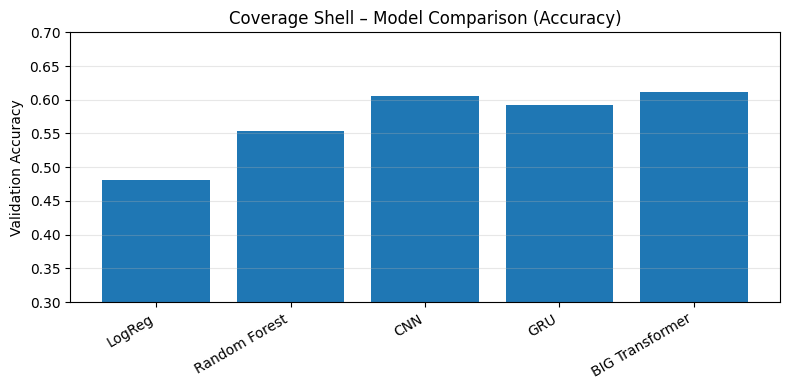

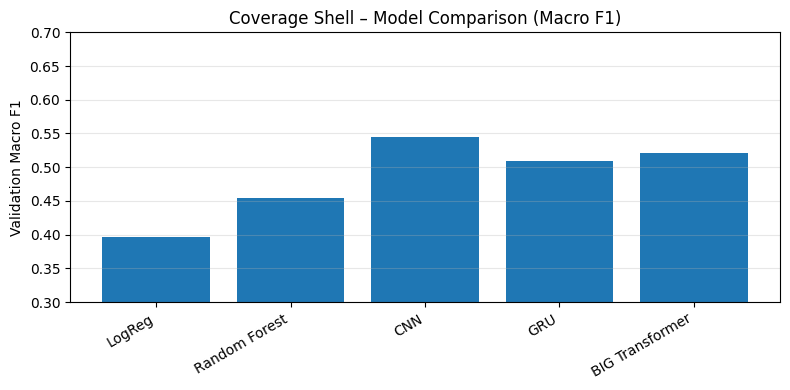

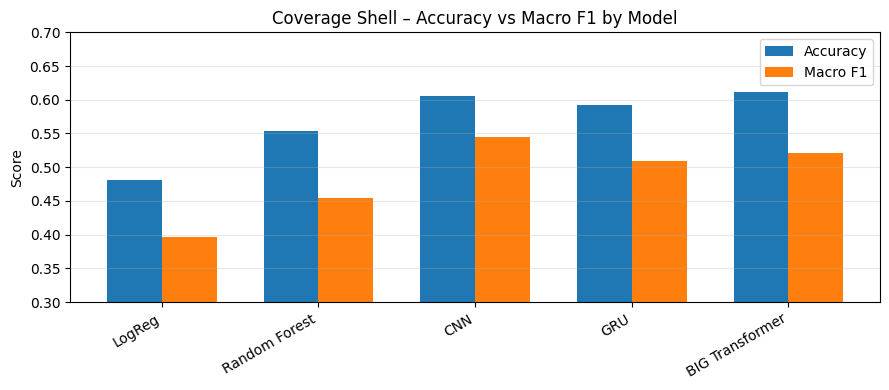

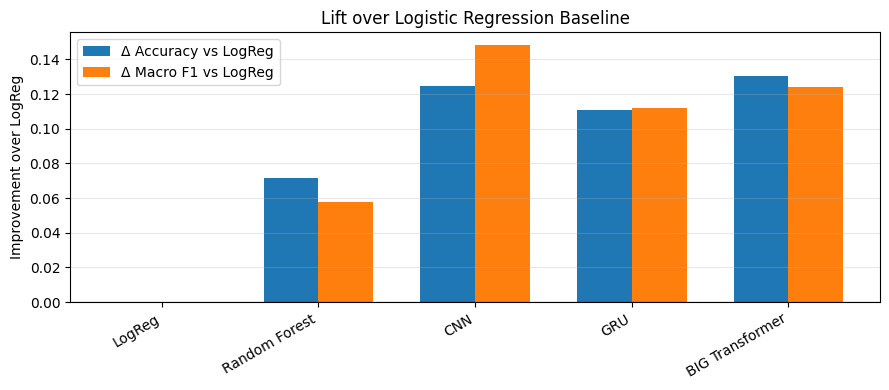

In [26]:
# ============================================================
# MODEL COMPARISON – FULL VISUAL SUITE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1) Validation metrics for each model
# ------------------------------------------------------------------

model_names = [
    "LogReg",
    "Random Forest",
    "CNN",
    "GRU",
    "BIG Transformer",
]

# Validation ACCURACY for each model
val_acc = np.array([
    0.4815,   # LogReg Accuracy
    0.5532,   # RF Accuracy
    0.6063,   # CNN Accuracy
    0.5925,   # GRU Accuracy
    0.6118,   # BIG Transformer Accuracy
])

# Validation MACRO F1 for each model
val_f1 = np.array([
    0.3966,   # LogReg Macro F1
    0.4545,   # RF Macro F1
    0.5448,   # CNN Macro F1
    0.5085,   # GRU Macro F1
    0.5209,   # BIG Transformer Macro F1
])

assert len(model_names) == len(val_acc) == len(val_f1)


# ------------------------------------------------------------------
# 2) Text summary
# ------------------------------------------------------------------

print("Validation metrics by model:")
print("-" * 60)
print(f"{'Model':16s} | {'Acc':>7s} | {'Macro F1':>7s}")
print("-" * 60)
for name, acc, f1 in zip(model_names, val_acc, val_f1):
    print(f"{name:16s} | {acc:7.3f} | {f1:7.3f}")
print("-" * 60)

best_acc_idx = val_acc.argmax()
best_f1_idx = val_f1.argmax()

print(f"Best Accuracy : {model_names[best_acc_idx]} ({val_acc[best_acc_idx]:.3f})")
print(f"Best Macro F1 : {model_names[best_f1_idx]} ({val_f1[best_f1_idx]:.3f})")

# naive 6-class random guess baseline just for context
random_baseline_acc = 1.0 / 6.0
print(f"\nRandom-guess 6-class accuracy baseline ≈ {random_baseline_acc:.3f}")
print(f"Top model Acc lift over random ≈ {val_acc[best_acc_idx] - random_baseline_acc:.3f}")


# ------------------------------------------------------------------
# 3) Bar plot – Validation Accuracy by model
# ------------------------------------------------------------------

x = np.arange(len(model_names))

plt.figure(figsize=(8, 4))
plt.bar(x, val_acc)
plt.xticks(x, model_names, rotation=30, ha="right")
plt.ylim(0.3, 0.7)
plt.ylabel("Validation Accuracy")
plt.title("Coverage Shell – Model Comparison (Accuracy)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# 4) Bar plot – Validation Macro F1 by model
# ------------------------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(x, val_f1)
plt.xticks(x, model_names, rotation=30, ha="right")
plt.ylim(0.3, 0.7)
plt.ylabel("Validation Macro F1")
plt.title("Coverage Shell – Model Comparison (Macro F1)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# 5) Grouped bar chart – Accuracy vs Macro F1 for each model
# ------------------------------------------------------------------

width = 0.35  # bar width

plt.figure(figsize=(9, 4))
plt.bar(x - width/2, val_acc, width=width, label="Accuracy")
plt.bar(x + width/2, val_f1, width=width, label="Macro F1")

plt.xticks(x, model_names, rotation=30, ha="right")
plt.ylim(0.3, 0.7)
plt.ylabel("Score")
plt.title("Coverage Shell – Accuracy vs Macro F1 by Model")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# 6) Improvement over LogReg baseline (ΔAcc and ΔF1)
# ------------------------------------------------------------------

baseline_acc = val_acc[0]
baseline_f1 = val_f1[0]

delta_acc = val_acc - baseline_acc
delta_f1 = val_f1 - baseline_f1

plt.figure(figsize=(9, 4))
plt.bar(x - width/2, delta_acc, width=width, label="Δ Accuracy vs LogReg")
plt.bar(x + width/2, delta_f1, width=width, label="Δ Macro F1 vs LogReg")

plt.axhline(0.0, color="black", linewidth=0.8)
plt.xticks(x, model_names, rotation=30, ha="right")
plt.ylabel("Improvement over LogReg")
plt.title("Lift over Logistic Regression Baseline")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



### Model Comparison and Per Class Analysis Visuals

This section builds all of the summary visuals for Deep CoverageNet, using the
saved validation metrics and predictions from the shell classifiers.

**Goal**

- Compare all five models side by side on validation accuracy and macro F1.
- Show how much each deep model improves over a simple logistic regression baseline.
- Drill down on the best model (currently the CNN) to understand which shells it
  handles well and where it struggles.

**Inputs**

- Aggregated validation metrics for each model:
  - `val_acc`: validation accuracy for  
    `["LogReg", "Random Forest", "CNN", "GRU", "BIG Transformer"]`
  - `val_f1`: validation macro F1 for the same models.
- For the best model only (CNN in this run):
  - `val_labels_ids`: true shell labels on the validation set.
  - `val_preds_ids`: predicted shell labels on the validation set.
  - `unique_labels`: numeric label ids kept in this run.
  - `target_names`: human readable shell names in the same order as `unique_labels`.

**What the code does**

1. **Model level comparison**
   - Prints a text table of accuracy and macro F1 for every model.
   - Identifies the best model under each metric and compares against a naive
     random guess baseline for six classes.
   - Creates three summary plots:
     - Bar chart of validation accuracy by model.
     - Bar chart of validation macro F1 by model.
     - Grouped bar chart showing accuracy vs macro F1 for each model.
   - Computes lift over logistic regression and plots:
     - Delta accuracy relative to LogReg.
     - Delta macro F1 relative to LogReg.

2. **Per class breakdown for the best model (CNN)**
   - Uses `precision_recall_fscore_support` to compute, for each shell:
     - precision, recall, F1, and support.
   - Prints a formatted table so you can see which shells are easiest or hardest.
   - Plots:
     - Bar chart of F1 score by shell.
     - Grouped bar chart of precision, recall, and F1 by shell.
   - Builds a confusion matrix for the best model using `confusion_matrix` and
     `ConfusionMatrixDisplay`, which shows:
     - where the model confuses C1 vs C3, C3 vs C4, or 2-MAN vs other man structures.
     - which shells have clean diagonals (highly consistent predictions).

**How this fits the story**

- The model comparison charts support the claim that deep sequence models
  (CNN, GRU, Transformer) outperform classical baselines on early coverage
  identification.
- The per class analysis and confusion matrix connect performance back to
  football structure, highlighting shells that are genuinely hard to separate
  early in the play and therefore candidates for high disguise quality.


Per-class metrics for best model (current: CNN):
----------------------------------------------------------------------
Class          |   Prec | Recall |     F1 | Support
----------------------------------------------------------------------
2-MAN          |  0.316 |  0.125 |  0.179 |      48
C0             |  0.476 |  0.570 |  0.519 |     121
C1             |  0.604 |  0.514 |  0.555 |     590
C2             |  0.724 |  0.617 |  0.666 |     412
C3             |  0.615 |  0.714 |  0.661 |     909
C4             |  0.511 |  0.519 |  0.515 |     455
----------------------------------------------------------------------
Macro F1 (from breakdown) = 0.516


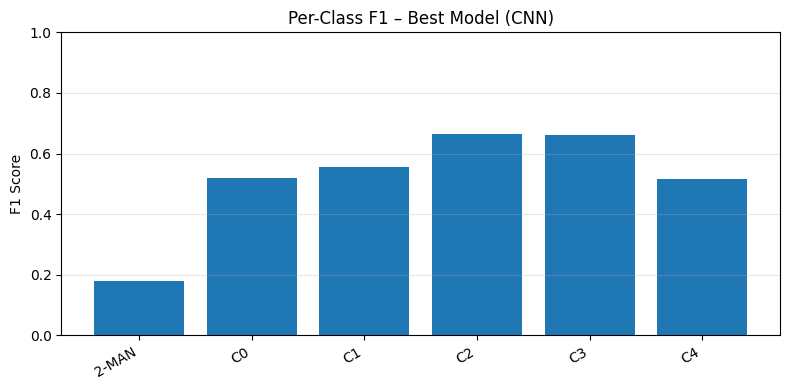

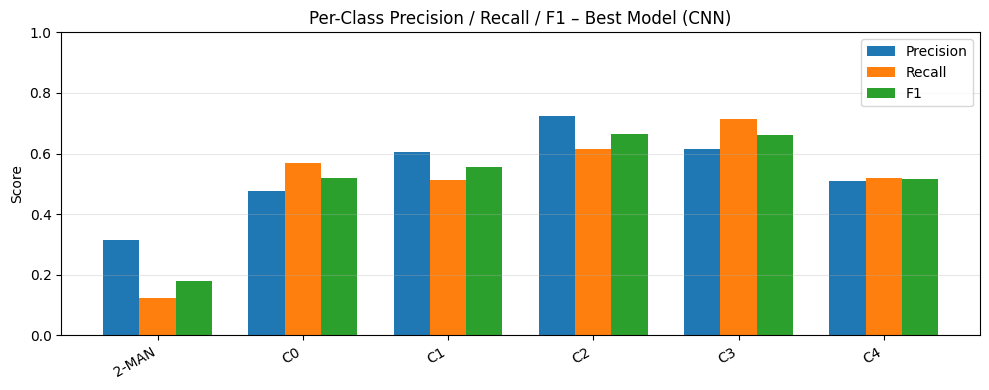

<Figure size 700x600 with 0 Axes>

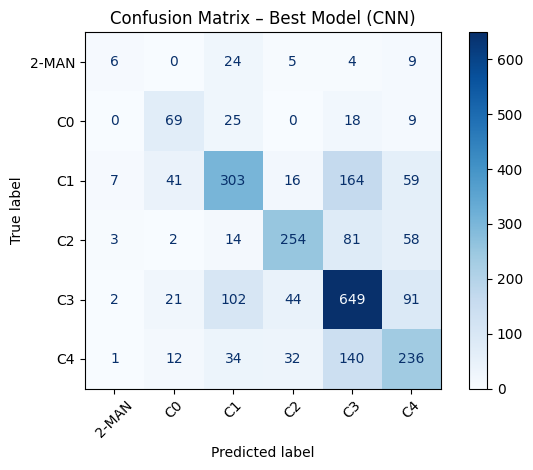

In [27]:
# ============================================================
# PER-CLASS ANALYSIS FOR BEST MODEL (e.g., CNN)
# Requires: val_labels_ids, val_preds_ids, unique_labels, target_names
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

# 1) Per-class precision, recall, F1, support
prec, rec, f1, support = precision_recall_fscore_support(
    val_labels_ids,
    val_preds_ids,
    labels=unique_labels,
    zero_division=0,
)

print("Per-class metrics for best model (current: CNN):")
print("-" * 70)
print(f"{'Class':14s} | {'Prec':>6s} | {'Recall':>6s} | {'F1':>6s} | {'Support':>7s}")
print("-" * 70)
for name, p, r, f, s in zip(target_names, prec, rec, f1, support):
    print(f"{name:14s} | {p:6.3f} | {r:6.3f} | {f:6.3f} | {s:7d}")
print("-" * 70)
print(f"Macro F1 (from breakdown) = {f1.mean():.3f}")


# 2) F1 by class (bar plot)
x = np.arange(len(target_names))

plt.figure(figsize=(8, 4))
plt.bar(x, f1)
plt.xticks(x, target_names, rotation=30, ha="right")
plt.ylim(0.0, 1.0)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 – Best Model (CNN)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 3) Precision / Recall / F1 grouped by class
width = 0.25

plt.figure(figsize=(10, 4))
plt.bar(x - width, prec, width=width, label="Precision")
plt.bar(x,         rec,  width=width, label="Recall")
plt.bar(x + width, f1,   width=width, label="F1")

plt.xticks(x, target_names, rotation=30, ha="right")
plt.ylim(0.0, 1.0)
plt.ylabel("Score")
plt.title("Per-Class Precision / Recall / F1 – Best Model (CNN)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 4) Confusion matrix (for the same model)
cm = confusion_matrix(val_labels_ids, val_preds_ids, labels=unique_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Best Model (CNN)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Confidence Analysis – Collecting Validation Probabilities

This cell gathers the **softmax probabilities** for every validation example so we can analyze how well the model’s confidence lines up with correctness (calibration, confidence histograms, threshold curves, etc.).

**What this cell does**

- Defines `get_val_probs(model, loader)`:
  - Runs the model in `eval()` mode with `torch.no_grad()` to disable gradient tracking.
  - For each batch in the validation loader:
    - Moves inputs to the correct device and computes logits.
    - Applies `softmax` over the class dimension to get predicted probabilities.
    - Accumulates probabilities and true labels on CPU.
  - Concatenates everything into two numpy arrays:
    - `all_probs`: shape `[N_val, num_classes]`, the softmax distribution per play.
    - `all_labels`: shape `[N_val]`, the corresponding ground-truth label indices.

- Calls `get_val_probs(model, val_loader)` to produce:
  - `val_probs`: full softmax matrix for the validation set.
  - `val_labels_idx_again`: labels returned alongside those probabilities.

- Uses an **assertion check** to verify that `val_labels_idx_again` matches the previously used `val_labels_ids`.  
  - This guards against any ordering mismatch between earlier evaluation code and this confidence-analysis pass.

- Prints the final probability matrix shape so we know how many samples and classes we are working with before building:
  - Correct vs incorrect confidence histograms,
  - Accuracy/F1 vs confidence-threshold curves,
  - Or any downstream “disguise index” / uncertainty-based metrics.


In [28]:
# =========================
# COLLECT VAL PROBABILITIES FOR CONFIDENCE ANALYSIS
# =========================

import torch.nn.functional as F

def get_val_probs(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device)

            logits = model(xb)
            probs = F.softmax(logits, dim=1)

            all_probs.append(probs.cpu())
            all_labels.append(yb.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_probs, all_labels


val_probs, val_labels_idx_again = get_val_probs(model, val_loader)

# Sanity: ensure alignment
assert (val_labels_ids == val_labels_idx_again).all(), "Label mismatch – ordering issue"
print("Softmax probabilities collected! Shape:", val_probs.shape)


Softmax probabilities collected! Shape: (2535, 6)


Accuracy vs Confidence Threshold

Purpose:
  - Use the CNN's softmax probabilities on the validation set (val_probs)
    to study how performance changes as we raise a confidence threshold.
  - For each threshold p ≥ {0.5, 0.6, 0.7, 0.8, 0.9}, we:
      * Keep only plays where the model’s max class probability ≥ threshold.
      * Compute:
          - accuracy on that subset
          - macro F1 on that subset
          - coverage = fraction of plays auto-tagged at that threshold.
  - This directly supports the selective auto-tagging workflow:
      * Lower threshold → more coverage, lower accuracy.
      * Higher threshold → less coverage, higher accuracy.

Inputs (expected to already exist in the notebook):
  - val_probs: [N, C] softmax probabilities for each validation play
  - val_labels_ids: [N] true shell IDs for validation plays
  - val_preds_ids: [N] predicted shell IDs for validation plays

Outputs:
  - Printed table of (threshold, coverage, accuracy, macro F1).
  - threshold_df: DataFrame summarizing these metrics.
  - Line plot showing how Accuracy, Macro F1, and Coverage vary with threshold.



Accuracy/F1 when we only auto-tag plays above a confidence threshold:

Threshold p ≥ 0.5: coverage=86.67%, Acc=0.640, Macro F1=0.548
Threshold p ≥ 0.6: coverage=71.28%, Acc=0.691, Macro F1=0.590
Threshold p ≥ 0.7: coverage=56.92%, Acc=0.724, Macro F1=0.593
Threshold p ≥ 0.8: coverage=39.92%, Acc=0.796, Macro F1=0.646
Threshold p ≥ 0.9: coverage=21.78%, Acc=0.870, Macro F1=0.711


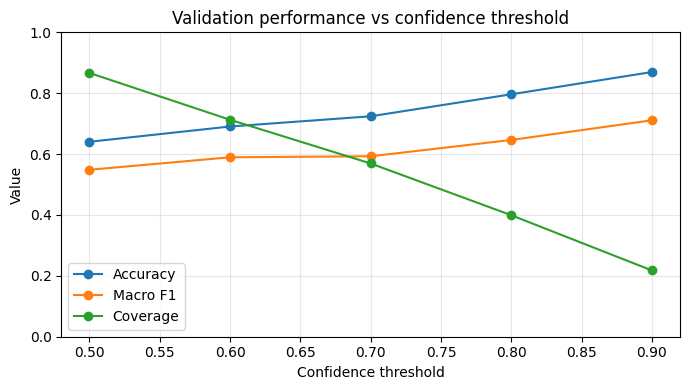

In [29]:
# =========================
# ACCURACY VS CONFIDENCE THRESHOLD
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# max model confidence per play
max_conf = val_probs.max(axis=1)  # shape [N]

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
rows = []

print("Accuracy/F1 when we only auto-tag plays above a confidence threshold:\n")
for thresh in thresholds:
    mask = max_conf >= thresh
    if mask.sum() == 0:
        continue

    acc_t = accuracy_score(val_labels_ids[mask], val_preds_ids[mask])
    f1_t  = f1_score(val_labels_ids[mask], val_preds_ids[mask], average="macro")
    coverage = mask.mean()

    rows.append((thresh, coverage, acc_t, f1_t))
    print(
        f"Threshold p ≥ {thresh:.1f}: "
        f"coverage={coverage:5.2%}, Acc={acc_t:.3f}, Macro F1={f1_t:.3f}"
    )

threshold_df = pd.DataFrame(rows, columns=["threshold", "coverage", "accuracy", "macro_f1"])

# Line plot: threshold → performance / coverage
plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["macro_f1"], marker="o", label="Macro F1")
plt.plot(threshold_df["threshold"], threshold_df["coverage"], marker="o", label="Coverage")
plt.xlabel("Confidence threshold")
plt.ylabel("Value")
plt.ylim(0, 1.0)
plt.title("Validation performance vs confidence threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Confidence Distribution: Correct vs Wrong

Purpose:
  - Visualize how the model’s confidence (max softmax probability) differs
    between correct and incorrect predictions on the validation set.
  - Helps diagnose calibration:
      * Well-calibrated models tend to assign high confidence to correct predictions
        and lower confidence to incorrect ones.
      * A strong separation between the two histograms indicates meaningful confidence signal.

What we compute:
  - max_conf: [N] vector of each play’s highest predicted class probability.
  - correct_mask: boolean mask showing which predictions were correct.
  - Two histograms:
      * max_conf[correct_mask]
      * max_conf[~correct_mask]

Interpretation:
  - If the "Correct" histogram concentrates near 0.8–1.0 and the "Incorrect" histogram
    concentrates near 0.4–0.7, the model has good discriminative calibration.
  - This supports selective auto-tagging: when confidence is high, accuracy tends to be high.

Inputs required (already computed earlier in the notebook):
  - val_probs: [N, C] softmax probabilities for each validation play.
  - val_labels_ids: [N] true shell labels.
  - val_preds_ids: [N] predicted shell labels.

Output:
  - A pair of overlaid histograms showing the distribution of confidence
    for correct vs incorrect predictions.



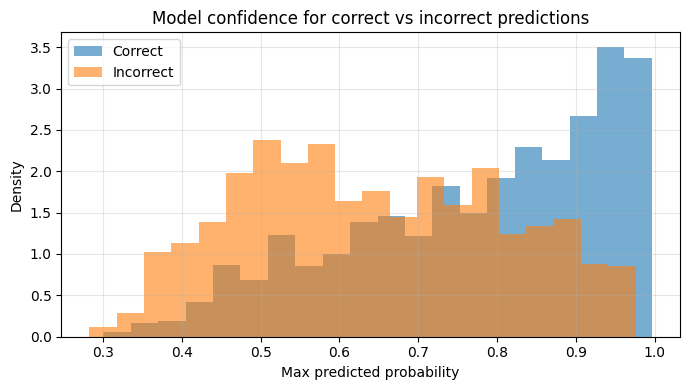

In [30]:
# =========================
# CONFIDENCE DISTRIBUTION: CORRECT VS WRONG
# =========================

correct_mask = (val_labels_ids == val_preds_ids)

plt.figure(figsize=(7, 4))
plt.hist(max_conf[correct_mask], bins=20, alpha=0.6, label="Correct", density=True)
plt.hist(max_conf[~correct_mask], bins=20, alpha=0.6, label="Incorrect", density=True)
plt.xlabel("Max predicted probability")
plt.ylabel("Density")
plt.title("Model confidence for correct vs incorrect predictions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Top-K High-Confidence Correct vs Incorrect Examples

Purpose:
  - Identify which validation plays the model is *most* confident about, both when it is right
    and when it is wrong.
  - These examples help us understand:
      * What “easy” plays look like for the model (clear structural cues).
      * What “deceptive” or ambiguous plays look like (often true disguise).
      * Whether high-confidence mistakes cluster in certain shells (e.g., C3 ↔ C4).

Method:
  - Compute model confidence per play using `val_probs` (softmax outputs).
  - Define:
        correct_idx  = plays where predicted shell == true shell
        wrong_idx    = plays where predicted shell != true shell
  - Sort each group by descending confidence:
        correct_sorted = highest-confidence correct predictions
        wrong_sorted   = highest-confidence *incorrect* predictions
  - For each play, extract:
        • true shell
        • predicted shell
        • top-2 highest probability classes
        • confidence values for top-1 and top-2

Inputs expected to already exist:
  - val_probs: [N, C] softmax probabilities for each validation play
  - val_labels_ids: [N] true shell IDs for validation plays
  - val_preds_ids: [N] predicted shell IDs for validation plays
  - unique_labels, target_names: consistent label mappings used throughout notebook

Output:
  - Two DataFrames:
        `high_conf_correct`   : top-K highest-confidence correct predictions
        `high_conf_wrong`     : top-K highest-confidence incorrect predictions
  - These tables are useful for qualitative review, understanding failure modes,
    and diagnosing where early-frame disguise is most impactful.


In [31]:
# =========================
# TOP-K HIGH-CONFIDENCE CORRECT / INCORRECT EXAMPLES
# =========================

# Map shell ID -> human-readable name
id_to_name = {lbl: name for lbl, name in zip(unique_labels, target_names)}

correct_idx = np.where(val_labels_ids == val_preds_ids)[0]
wrong_idx   = np.where(val_labels_ids != val_preds_ids)[0]

# sort by confidence descending
correct_sorted = correct_idx[np.argsort(-max_conf[correct_idx])]
wrong_sorted   = wrong_idx[np.argsort(-max_conf[wrong_idx])]

K = 10  # how many to show

def build_example_df(indices, label):
    rows = []
    for i in indices[:K]:
        probs_i = val_probs[i]
        top2 = np.argsort(-probs_i)[:2]
        best, second = top2[0], top2[1]

        true_id = val_labels_ids[i]
        pred_id = val_preds_ids[i]

        rows.append({
            "val_index": int(i),
            "true_shell":   id_to_name[true_id],
            "pred_shell":   id_to_name[pred_id],
            "top2_second_shell": id_to_name[unique_labels[second]],
            "conf_top1": float(probs_i[best]),
            "conf_top2": float(probs_i[second]),
        })
    return pd.DataFrame(rows)

high_conf_correct = build_example_df(correct_sorted, "correct")
high_conf_wrong   = build_example_df(wrong_sorted, "wrong")

print("\nTop high-confidence CORRECT predictions:")
display(high_conf_correct)

print("\nTop high-confidence INCORRECT predictions:")
display(high_conf_wrong)



Top high-confidence CORRECT predictions:


,val_index,true_shell,pred_shell,top2_second_shell,conf_top1,conf_top2
0,618,C2,C2,C3,0.996483,0.001508
1,617,C2,C2,C3,0.996112,0.001718
2,1413,C2,C2,C4,0.995985,0.001900
3,2170,C2,C2,C3,0.995339,0.002735
4,1611,C2,C2,2-MAN,0.995035,0.002209
5,186,C2,C2,2-MAN,0.994797,0.002495
6,1354,C2,C2,C4,0.994130,0.003689
7,1471,C2,C2,C3,0.993897,0.002303
8,2090,C2,C2,C4,0.993802,0.004782
9,503,C2,C2,C4,0.993390,0.003945



Top high-confidence INCORRECT predictions:


,val_index,true_shell,pred_shell,top2_second_shell,conf_top1,conf_top2
0,1071,2-MAN,C2,C4,0.975790,0.009172
1,1832,C3,C1,C3,0.972001,0.024559
2,2108,C3,C2,C3,0.968031,0.023289
3,1430,C4,C0,C1,0.966213,0.023730
4,210,C4,C3,C1,0.963957,0.023575
5,151,C3,C1,C3,0.962751,0.034011
6,2162,C3,C1,C3,0.962522,0.030348
7,466,2-MAN,C1,C4,0.960627,0.015560
8,1732,C2,C3,C4,0.958500,0.021665
9,1460,C2,C1,C0,0.957853,0.014731


### Class Distribution Plot (Coverage Shell Frequencies)

This cell visualizes how often each coverage shell appears in the full dataset.  
Understanding class balance is important because **imbalanced labels directly affect model learning**, calibration, and confusion patterns.

**Purpose**

- Load all shell labels (`y_shell.pt`) generated during preprocessing.  
- Count how many samples belong to each shell class.  
- Produce a simple bar chart to show dataset imbalance.  
- This helps explain:
  - Why some classes (e.g., C2, C3) achieve higher F1 — more examples, clearer structure.  
  - Why rare classes (e.g., 2-MAN) are harder to learn and often misclassified.  
  - Why deep models outperform baselines: they capture structure even with skewed distributions.

**Inputs**

- `y_shell.pt`: integer shell labels for all plays.  
- `target_names`: human-readable shell names (C1, C2, etc.).  
- `unique_labels`: numeric IDs aligned with `target_names`.

**Output**

- Bar chart showing sample frequency for each shell class.  
- A DataFrame (`class_counts`) displaying exact counts.

This plot supports your “Data Understanding” and “Model Behavior” sections by grounding the class-level performance patterns in the underlying label distribution.


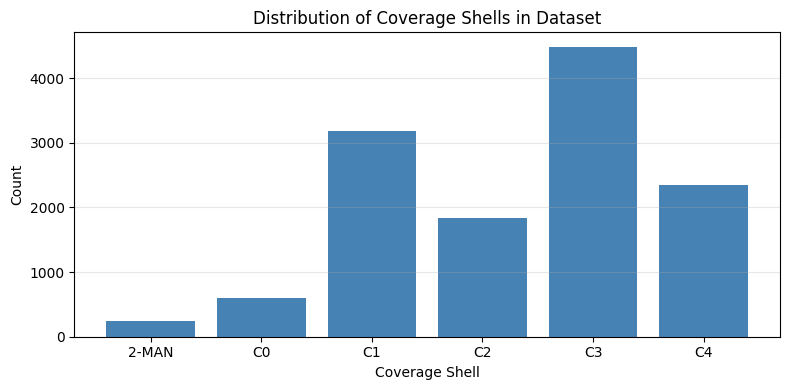

,shell,count
0,2-MAN,237
1,C0,601
2,C1,3175
3,C2,1837
4,C3,4482
5,C4,2346


In [32]:
# ================================
# CLASS DISTRIBUTION PLOT
# ================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Load full dataset labels (y_shell)
y_shell = torch.load("coverage_processed/y_shell.pt")  # shape [N]
all_labels = np.array(y_shell)

# Build DataFrame
class_counts = pd.DataFrame({
    "shell": target_names,
    "count": [np.sum(all_labels == i) for i in unique_labels]
})

# Plot
plt.figure(figsize=(8,4))
plt.bar(class_counts["shell"], class_counts["count"], color="steelblue")
plt.xlabel("Coverage Shell")
plt.ylabel("Count")
plt.title("Distribution of Coverage Shells in Dataset")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

class_counts

